# APIs
## Step 1: Create a Spotify Developer Account
## Step 2: Initial Setup


In [30]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv


## Step 3: Environment Variables

In [31]:
load_dotenv()

True

In [32]:
client_id = os.environ.get("CLIENT_ID")
client_secret = os.environ.get("CLIENT_SECRET")

## Step 4: Initialize the Spotipy Library

In [33]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials

auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
spotify = spotipy.Spotify(auth_manager=auth_manager, requests_timeout=30)

## Step 5: Make API Requests

In [34]:
track_id_1 = "1UbwpyozDvufPs6aNPW3ti"
track_1 = spotify.track(track_id_1)

print(f"Track Name: {track_1['name']}")
print(f"Artist: {track_1['artists'][0]['name']}")
print(f"Album: {track_1['album']['name']}")
print(f"Release Date: {track_1['album']['release_date']}")


track_id_2 = "5Plx6OhvSukqCRdZ52wUXz"
track_2 = spotify.track(track_id_2)

print(f"Track Name: {track_2['name']}") 
print(f"Artist: {track_2['artists'][0]['name']}")
print(f"Album: {track_2['album']['name']}")
print(f"Release Date: {track_2['album']['release_date']}")

track_id_3 = "3HMOMdRPywfouYx5B4PvaH"
track_3 = spotify.track(track_id_3)

print(f"Track Name: {track_3['name']}")
print(f"Artist: {track_3['artists'][0]['name']}")
print(f"Album: {track_3['album']['name']}")
print(f"Release Date: {track_3['album']['release_date']}")



Track Name: Ben's My Friend
Artist: Sun Kil Moon
Album: Benji
Release Date: 2014-08-19
Track Name: Farewell Transmission
Artist: Songs: Ohia
Album: Magnolia Electric Co. (Deluxe Edition)
Release Date: 2003-03-04
Track Name: Carry the Zero
Artist: Built To Spill
Album: Keep It like a Secret
Release Date: 1999-01-22



## Step 6: Transform to Pandas DataFrame

In [35]:
track_data = [
    {
        "track_id": track_1["id"],
        "name": track_1["name"],
        "artist": track_1["artists"][0]["name"],
        "album": track_1["album"]["name"],
        "release_date": track_1["album"]["release_date"],
        "popularity": track_1["popularity"]
    },
    {
        "track_id": track_2["id"],
        "name": track_2["name"],
        "artist": track_2["artists"][0]["name"],
        "album": track_2["album"]["name"],
        "release_date": track_2["album"]["release_date"],
        "popularity": track_2["popularity"]
    },
    {
        "track_id": track_3["id"],
        "name": track_3["name"],
        "artist": track_3["artists"][0]["name"],
        "album": track_3["album"]["name"],
        "release_date": track_3["album"]["release_date"],
        "popularity": track_3["popularity"]
    }
]

df_track = pd.DataFrame(track_data)
df_track = df_track.sort_values(by="popularity", ascending=False).reset_index(drop=True)
print(df_track)


                 track_id                   name          artist  \
0  3HMOMdRPywfouYx5B4PvaH         Carry the Zero  Built To Spill   
1  5Plx6OhvSukqCRdZ52wUXz  Farewell Transmission     Songs: Ohia   
2  1UbwpyozDvufPs6aNPW3ti        Ben's My Friend    Sun Kil Moon   

                                    album release_date  popularity  
0                   Keep It like a Secret   1999-01-22          56  
1  Magnolia Electric Co. (Deluxe Edition)   2003-03-04          53  
2                                   Benji   2014-08-19          51  


## Step 7: Analyze statistical relationship


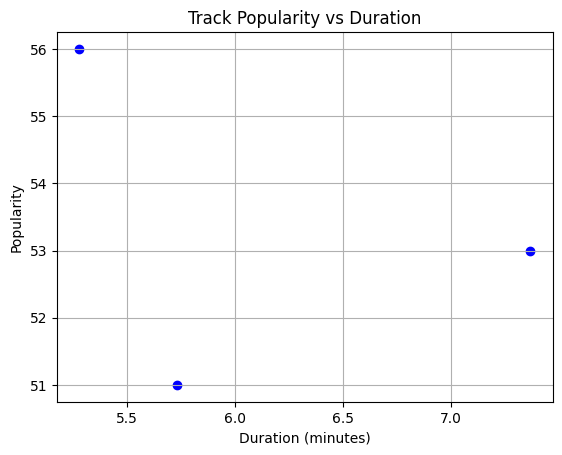

In [36]:
df_track["duration_min"] = [
    track["duration_ms"] / 60000 for track in [track_1, track_2, track_3]
]

plt.scatter(df_track["duration_min"], df_track["popularity"], color='blue')
plt.title("Track Popularity vs Duration")
plt.xlabel("Duration (minutes)")
plt.ylabel("Popularity")
plt.grid()


### Conclusion step 7

there is no correlation between the duration of a song and its popularity. This suggests that the length of a song does not significantly influence how well it performs in terms of popularity on Spotify.

## Feeling like diving deeper? 😎 

In [37]:
artist_id = "2UwqpfQtNuhBwviIC0f2ie"
artist = spotify.artist_top_tracks(artist_id)

tracks = []
for track in artist["tracks"]:
    tracks.append({
        "track_id": track["id"],
        "name": track["name"],
        "popularity": track["popularity"],
        "duration_ms": track["duration_ms"]
    })


In [ ]:
'''
tracks_id = [track["track_id"] for track in tracks]
track_features = spotify.audio_features(tracks_id)
'''

ReadTimeout: HTTPSConnectionPool(host='api.spotify.com', port=443): Read timed out. (read timeout=30)